In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d ayushmandatta1/deepdetect-2025
!unzip deepdetect-2025.zip

Streaming output truncated to the last 5000 lines.
  inflating: ddata/train/real/61451.jpg  
  inflating: ddata/train/real/61453.jpg  
  inflating: ddata/train/real/61455.jpg  
  inflating: ddata/train/real/61456.jpg  
  inflating: ddata/train/real/61458.jpg  
  inflating: ddata/train/real/61459.jpg  
  inflating: ddata/train/real/61460.jpg  
  inflating: ddata/train/real/61461.jpg  
  inflating: ddata/train/real/61464.jpg  
  inflating: ddata/train/real/61465.jpg  
  inflating: ddata/train/real/61466.jpg  
  inflating: ddata/train/real/61467.jpg  
  inflating: ddata/train/real/61468.jpg  
  inflating: ddata/train/real/61469.jpg  
  inflating: ddata/train/real/61470.jpg  
  inflating: ddata/train/real/61472.jpg  
  inflating: ddata/train/real/61475.jpg  
  inflating: ddata/train/real/61476.jpg  
  inflating: ddata/train/real/61477.jpg  
  inflating: ddata/train/real/61478.jpg  
  inflating: ddata/train/real/61479.jpg  
  inflating: ddata/train/real/61481.jpg  
  inflating: ddata/train/

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input  # ✅ Fix #1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 10
base_dir    = "/content/ddata"
train_dir   = base_dir + "/train"
test_dir    = base_dir + "/test"

In [5]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ✅ correct preprocessing
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,                      # ✅ added
    brightness_range=[0.8, 1.2],               # ✅ added
    width_shift_range=0.1,                     # ✅ added
    height_shift_range=0.1,                    # ✅ added
    validation_split=0.2
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input    # ✅ correct preprocessing
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False                              # ✅ no shuffle on val
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False                              # ✅ must be False for evaluation
)

# ✅ Always verify — with your folder names: {'fake': 0, 'real': 1}
print("Class mapping:", train_data.class_indices)
# fake=0 → pred <= 0.5 means FAKE
# real=1 → pred >  0.5 means REAL


Found 72328 images belonging to 2 classes.
Found 18081 images belonging to 2 classes.
Found 21776 images belonging to 2 classes.
Class mapping: {'fake': 0, 'real': 1}


In [6]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze bottom 70%, unfreeze top 30% for fine-tuning
total_layers = len(base_model.layers)
freeze_until = int(0.7 * total_layers)

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
for layer in base_model.layers[freeze_until:]:
    layer.trainable = True

print(f"Total layers: {total_layers} | Frozen: {freeze_until} | Trainable: {total_layers - freeze_until}")

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.6)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

# ✅ Added AUC metric
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layers: 238 | Frozen: 166 | Trainable: 72


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 3,407,325 (13.00 MB)

 Non-trainable params: 970,439 (3.70 MB)

In [7]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        min_lr=1e-7,
        verbose=1
    )
]

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 1324s 566ms/step - accuracy: 0.6575 - auc: 0.7159 - loss: 0.6046 - val_accuracy: 0.8469 - val_auc: 0.9247 - val_loss: 0.3581 - learning_rate: 1.0000e-05
Epoch 2/10
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 1284s 552ms/step - accuracy: 0.8367 - auc: 0.9166 - loss: 0.3672 - val_accuracy: 0.8996 - val_auc: 0.9650 - val_loss: 0.2471 - learning_rate: 1.0000e-05
Epoch 3/10
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 1230s 544ms/step - accuracy: 0.8823 - auc: 0.9529 - loss: 0.2775 - val_accuracy: 0.9170 - val_auc: 0.9780 - val_loss: 0.2030 - learning_rate: 1.0000e-05
Epoch 4/10
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 1236s 546ms/step - accuracy: 0.9085 - auc: 0.9682 - loss: 0.2280 - val_accuracy: 0.9330 - val_auc: 0.9854 - val_loss: 0.1671 - learning_rate: 1.0000e-05
Epoch 5/10
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 1235s 546ms/step - accuracy: 0.9215 - auc: 0.9756 - loss: 0.1989 - val_accuracy: 0.9436 - val_auc: 0.9883 - val_loss: 0.1446 - learning_rate: 1.0000e-05
Epoch 6/10
2261/2261 ━━━━


--- Test Set Evaluation ---
681/681 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - accuracy: 0.8830 - auc: 0.4742 - loss: 0.3228
Test Loss     : 0.6594
Test Accuracy : 0.7652
Test AUC      : 0.9022

--- Classification Report ---
681/681 ━━━━━━━━━━━━━━━━━━━━ 58s 76ms/step
              precision    recall  f1-score   support

        Fake       0.68      0.94      0.79     10399
        Real       0.92      0.60      0.73     11377

    accuracy                           0.77     21776
   macro avg       0.80      0.77      0.76     21776
weighted avg       0.81      0.77      0.76     21776



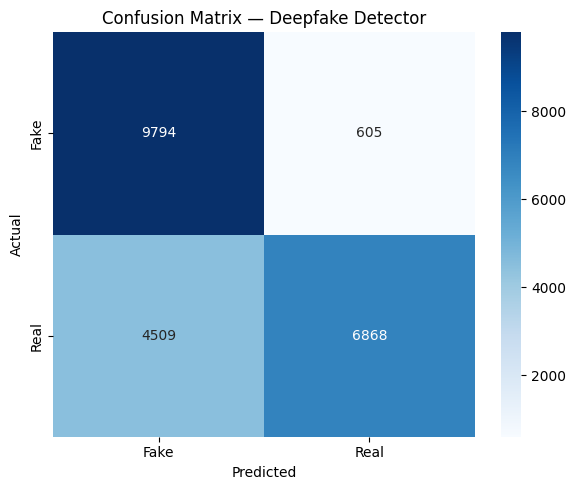

In [9]:
print("\n--- Test Set Evaluation ---")
test_loss, test_acc, test_auc = model.evaluate(test_data, verbose=1)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

# ✅ Detailed classification report
print("\n--- Classification Report ---")
y_pred_probs = model.predict(test_data).flatten()
y_pred       = (y_pred_probs > 0.5).astype(int)
y_true       = test_data.classes

print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Deepfake Detector")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()

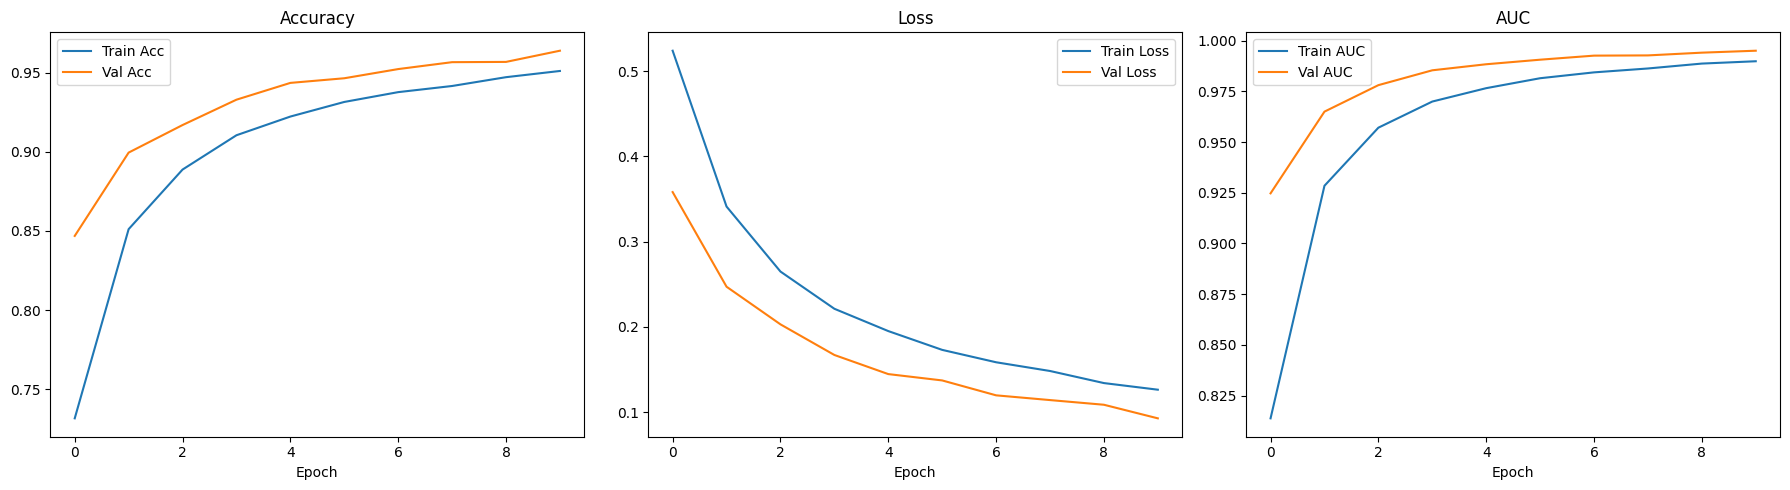

In [10]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history["accuracy"],     label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")

plt.subplot(1, 3, 2)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")
plt.xlabel("Epoch")

plt.subplot(1, 3, 3)
plt.plot(history.history["auc"],     label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC")
plt.xlabel("Epoch")

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()

In [11]:
model.save("/content/deepfake_detector_efficientnet_deepdetect2025.keras")
print("✅ Model saved as .keras")

model.save("/content/deepfake_detector_efficientnet_deepdetect2025.h5")
print("✅ Model saved as .h5")

✅ Model saved as .keras
✅ Model saved as .h5


In [34]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model, threshold=0.5):
    """
    Predict whether a single image is REAL or FAKE.
    Returns: label (str), confidence (float)
    """
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)         # shape: (224, 224, 3)
    img_array = preprocess_input(img_array)            # ✅ correct preprocessing
    img_array = np.expand_dims(img_array, axis=0)      # shape: (1, 224, 224, 3)

    pred = model.predict(img_array, verbose=0)[0][0]

    # class_indices: {'fake': 0, 'real': 1}
    # pred > 0.5  → closer to 1 → REAL
    # pred <= 0.5 → closer to 0 → FAKE
    if pred > threshold:
        label      = "REAL"
        confidence = pred
    else:
        label      = "FAKE"
        confidence = 1 - pred

    print(f"Prediction  : {label}")
    print(f"Confidence  : {confidence * 100:.2f}%")
    print(f"Raw score   : {pred:.4f}  (>0.5 = REAL, <=0.5 = FAKE)")
    return label, float(confidence)

# Example usage — change path to any image you want to test
img_path = "/content/ddata/test/real/real_045539.jpg"
label, confidence = predict_image(img_path, model)



Prediction  : REAL
Confidence  : 60.24%
Raw score   : 0.6024  (>0.5 = REAL, <=0.5 = FAKE)
